# TAREA 1: Clasificación

En esta parte del poryecto vamos a construir modelos de clasificación supervisada para predecir si la situación final del estudiante será Abandono, Matriculado o Graduado.

Para ello, vamos a comparar tres modelos diferentes:
- KNN: modelo básico basado en distancias para utilizar como primera predicción, para tomar una idea.
- Regresión Logística: modelo lineal, más rápido e interpretable.
- Random Forest: robusto y capaz de capturar relaciones no lineales. Esperamos que devuelva los mejores resultados de entre los tres modelos. 

## 1. Importaciones

In [62]:

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sys, os

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

sys.path.append(os.path.abspath(".."))
from src.preprocesado import plot_confusion

## 2. Carga de datos       
Cargamos el dataset preprocesado en EDA, separamos la variable objetivo y la codificamos numericamente con LabelEncoder.

In [63]:
df = pd.read_pickle("../data/df_limpio.pkl")

# Separar variables predictoras y variable objetivo
X = df.drop('objetivo', axis=1)
y = df['objetivo']

print('Dimensiones de X:', X.shape)
print('Distribución de la variable objetivo:')
print(y.value_counts(normalize=True).mul(100))

Dimensiones de X: (4424, 35)
Distribución de la variable objetivo:
objetivo
graduado       49.932188
abandono       32.120253
matriculado    17.947559
Name: proportion, dtype: float64


In [64]:
le = LabelEncoder()
y_cod = le.fit_transform(y)

mapeo = pd.DataFrame({'Clase original': le.classes_, 'Etiqueta numérica': le.transform(le.classes_)})
display(mapeo)

,Clase original,Etiqueta numérica
0,abandono,0
1,graduado,1
2,matriculado,2


### 2.1 Separación de columnas y división de train y test       
Dividimos el dataset en 80% entrenamiento y 20% test con la función train_test_split y usando stratify para mantener las proporciones de clase en ambas particiones.

> **Nota:** voy a optar por no tener en cuenta las variables del segundo semestre como predictoras. Aunque incluirlas mejoraría la predicción porque el rendimiento del segundo semestre es muy informativo sobre el resultado final, creo que puede ser más interesante tratar de predecir sin ellas. Así que veamos que ocurre.

In [65]:
columnas_categoricas_bin = [
    'desplazado', 'es_mujer', 'internacional', 'asistencia_diurna',
    'necesidades_educativas_especiales', 'deudor', 'matricula_al_dia', 'becado'
]
columnas_categoricas = [
    'estado_civil', 'modo_solicitud', 'curso',
    'cualificacion_previa', 'cualificacion_madre', 'cualificacion_padre',
    'ocupacion_madre', 'ocupacion_padre'
]
columnas_numericas = [
    'edad_al_matricularse', 'orden_solicitud', 'nota_cualificacion_previa', 'nota_admision',
    'tasa_desempleo', 'tasa_inflacion', 'pib',
    'asignaturas_1sem_convalidadas', 'asignaturas_1sem_matriculadas',
    'asignaturas_1sem_evaluadas', 'asignaturas_1sem_aprobadas',
    'nota_media_1sem', 'asignaturas_1sem_sin_evaluacion'
]


In [66]:
# Excluimos la variable objetivo y todas las del segundo semestre
cols_2sem = [col for col in df.columns if '2sem' in col]
cols_excluir = ['objetivo'] + cols_2sem

X = df.drop(columns=cols_excluir)

print("Columnas excluidas (2º semestre):", cols_2sem)
print("Columnas incluidas como predictores:", list(X.columns))
print(f"Total predictores: {X.shape[1]}")

Columnas excluidas (2º semestre): ['asignaturas_2sem_convalidadas', 'asignaturas_2sem_matriculadas', 'asignaturas_2sem_evaluadas', 'asignaturas_2sem_aprobadas', 'nota_media_2sem', 'asignaturas_2sem_sin_evaluacion']
Columnas incluidas como predictores: ['estado_civil', 'modo_solicitud', 'orden_solicitud', 'curso', 'asistencia_diurna', 'cualificacion_previa', 'nota_cualificacion_previa', 'cualificacion_madre', 'cualificacion_padre', 'ocupacion_madre', 'ocupacion_padre', 'nota_admision', 'desplazado', 'necesidades_educativas_especiales', 'deudor', 'matricula_al_dia', 'es_mujer', 'becado', 'edad_al_matricularse', 'internacional', 'asignaturas_1sem_convalidadas', 'asignaturas_1sem_matriculadas', 'asignaturas_1sem_evaluadas', 'asignaturas_1sem_aprobadas', 'nota_media_1sem', 'asignaturas_1sem_sin_evaluacion', 'tasa_desempleo', 'tasa_inflacion', 'pib']
Total predictores: 29


In [67]:
# División del conjunto de datos
X_train, X_test, y_train, y_test = train_test_split(X, y_cod, test_size=0.2, stratify=y_cod, random_state=42)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)

X_train: (3539, 29)
X_test: (885, 29)


### 2.2 Escalado y One-hot encoding      
Para evitar data leakage en la validación cruzada, el escalado y one-hot encoding lo integramos dento de un Pipeline de sklearn. Para garantizar que las funciones StandardScaler y OneHotEncoder se ajustan unnicamente con los datos de train de cada fold, y solo se aplican sobre el fold de validación.

También cabe mencionar que es importante estandarizar las variables con StandardScaler, especialmente para KNN y Regresión Logística, porque ambos son sensibles a la escala de las variables. Es decir, si una columna tiene valores mucho más grandes que otra, podría dominar el aprendizaje sin que eso signifique que sea más importante.

In [68]:
# ColumnTransformer: aplica transformaciones distintas según el tipo de columna
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), columnas_numericas),
                                               ('bin', 'passthrough', columnas_categoricas_bin),
                                               ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), columnas_categoricas)])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados = [] # para hacer una comparación al final

## Modelo 1: K-NEAREST NEIGHBORS     
KNN clasifica cada observación fijándose en las etiquetas de sus k vecinos más cercanos. Sabiendo que no es un modelo muy fiable ni preciso, es un modelo útil como primer análisis porque es intuitivo de iterpretar y permite capturar fronteras de decisión no lineales. Aunque, su principal incoveniente es de que depende mucho de la escala y de la elección de k. Para esos problemas, el escalado previo es imprescindible y para buscar el número de vecinos óptimo para nuestros datos utilizaremos validación cruzada.

Primero realizamos una búsqueda manual del rango de k para visualizar el comportamiento del modelo, y después una búsqueda más exhaustiva con GridSearchCV.

### Búsqueda manual de k     
Evaluamos k entre 1 y 30 con validación cruzada (5 folds). Sin embargo, esta búsqueda es apriximada ya que no optimiza el tipo de distancia ni la ponderación de vecinos, como sí hace GridSearch.

In [69]:
valores_k = range(1, 31)
medias = {}

for k in valores_k:
    pipe_knn = Pipeline([
        ('prep', preprocessor),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe_knn, X_train, y_train, cv=5, scoring='f1_macro')
    medias[k] = scores.mean()

mejor_k = max(medias, key=medias.get)
print("Mejor k (búsqueda manual):", mejor_k)
print("Mejor media f1_macro:", medias[mejor_k])

Mejor k (búsqueda manual): 7
Mejor media f1_macro: 0.5529368890719238


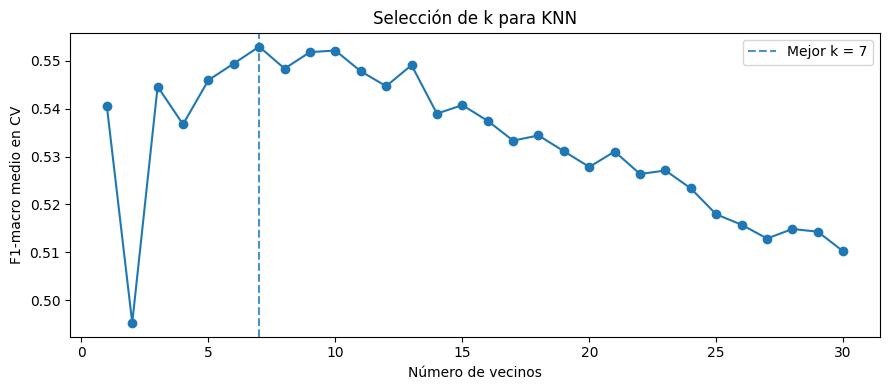

In [70]:
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(list(valores_k), list(medias.values()), marker='o')
ax.axvline(mejor_k, linestyle='--', alpha=0.8, label=f"Mejor k = {mejor_k}")
ax.set_xlabel("Número de vecinos")
ax.set_ylabel("F1-macro medio en CV")
ax.set_title("Selección de k para KNN")
ax.legend()
plt.tight_layout()
plt.show()

Esta gráfica ayuda a entender el equilibrio entre el overfitting que puede causar un valor pequeño de k y el underfitting de los valores grandes.   
Para quedarme con un modelo y una selección más precisa de k voy a utilizar Grid con particiones estratificadas, para que se mantenga la misma proporción de clases, y optimizo f1-macro, que es una métrica muy útil cuando se trabajo con muchas clases.

### GridSearchCV

Mejores parámetros KNN:  {'clf__metric': 'manhattan', 'clf__n_neighbors': 9, 'clf__weights': 'distance'}
Mejor F1-macro:  0.5681099822622631
Resultados en test:
Accuracy:  0.6519774011299435
F1-macro:  0.5346842128513289
              precision    recall  f1-score   support

    abandono       0.77      0.47      0.58       284
    graduado       0.66      0.94      0.77       442
 matriculado       0.38      0.19      0.25       159

    accuracy                           0.65       885
   macro avg       0.60      0.53      0.53       885
weighted avg       0.64      0.65      0.62       885



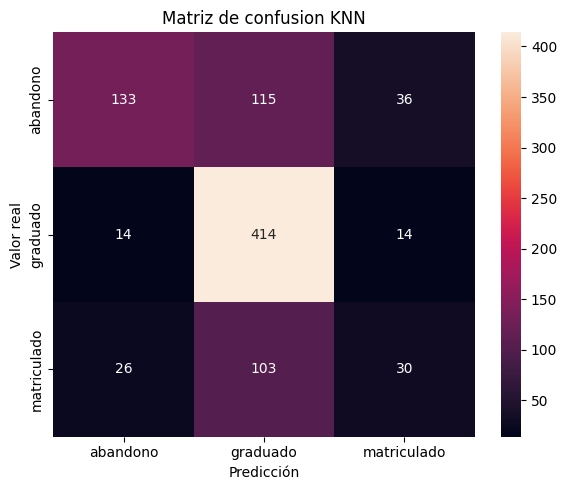

In [71]:
# Pipeline: primero escala y codifica, y luego aplica KNN
pipe_knn = Pipeline([('prep', preprocessor),
                     ('clf', KNeighborsClassifier())])
param_knn = {'clf__n_neighbors': [3,5,7,9,11,13,15],
             'clf__weights': ['uniform', 'distance'],
             'clf__metric': ['euclidean', 'manhattan']}

# Aplicamos GridSearch con los parámetros puestos
knn = GridSearchCV(pipe_knn, param_grid=param_knn, cv=cv, scoring='f1_macro', n_jobs=-1)
knn.fit(X_train, y_train)

print("Mejores parámetros KNN: ", knn.best_params_)
print("Mejor F1-macro: ", knn.best_score_)

# Evalua el mejor modelo encontrado en test
preds_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, preds_knn)
f1_knn = f1_score(y_test, preds_knn, average='macro')

print("Resultados en test:")
print("Accuracy: ", acc_knn)
print("F1-macro: ", f1_knn)
print(classification_report(y_test, preds_knn, target_names=le.classes_))

plot_confusion(y_test, preds_knn, le.classes_, 'Matriz de confusion KNN')

# Guardamos resultados para la comparación final
resultados.append({'Modelo': 'KNN', 'Accuracy': acc_knn, 'F1_macro': f1_knn})


## Modelo 2: REGRESIÓN LOGÍSTICA       
Regresión logística es un modelo lineal que estima probabilidades para cada clase a partir de una combinación ponderada de las variables de entrada. Aunque no es un modelo muy complejo, sirve como base sólida, es rápida de entrenar y es facil de interpretar. Usamos class_weight='balanced' para compensar posibles desbalanceos entre clases, y buscamos el parámetro de regularización C mediante GridSearch.

Mejores parámetros Regresión Logística: {'clf__C': 1}
Mejor F1-macro CV: 0.6816989985650005
Resultados en test:
Accuracy:  0.6926553672316385
F1-macro:  0.6449155912510913
              precision    recall  f1-score   support

    abandono       0.76      0.64      0.69       284
    graduado       0.85      0.79      0.82       442
 matriculado       0.36      0.53      0.43       159

    accuracy                           0.69       885
   macro avg       0.65      0.65      0.64       885
weighted avg       0.73      0.69      0.71       885



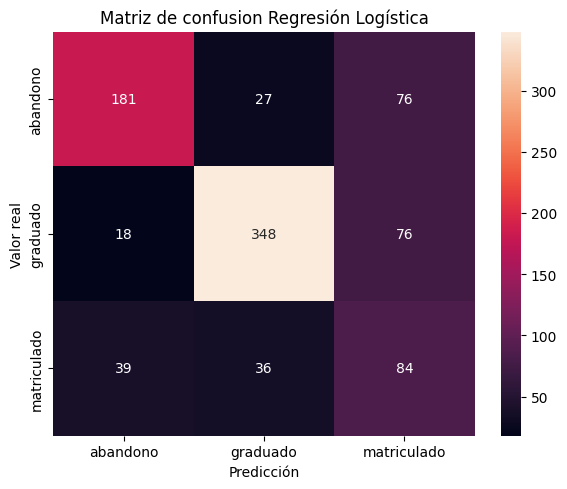

In [72]:
pipe_logreg = Pipeline([('prep', preprocessor),
                    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))])

param_logreg = {'clf__C': [0.01, 0.1, 1, 10, 100]}

logreg = GridSearchCV(pipe_logreg, param_grid=param_logreg, cv=cv, scoring='f1_macro', n_jobs=-1)
logreg.fit(X_train, y_train)

print("Mejores parámetros Regresión Logística:", logreg.best_params_)
print("Mejor F1-macro CV:", logreg.best_score_)

# Predecimos con test
preds_logreg = logreg.predict(X_test)
acc_logreg = accuracy_score(y_test, preds_logreg)
f1_logreg = f1_score(y_test, preds_logreg, average='macro')

print("Resultados en test:")
print("Accuracy: ", acc_logreg)
print("F1-macro: ", f1_logreg)
print(classification_report(y_test, preds_logreg, target_names=le.classes_))

plot_confusion(y_test, preds_logreg, le.classes_, 'Matriz de confusion Regresión Logística')

# Guardamos resultados para la comparación final
resultados.append({'Modelo': 'Regresión Logística', 'Accuracy': acc_logreg, 'F1_macro': f1_logreg})

## Modelo 3: RANDOM FOREST  
Random Forest combina muchos árboles de decisión entrenados sobre muestras y subconjuntos de variables distintos, lo que reduce la varianza respecto a un arbol individual. 

Seguimos el mismo procedimiento que con los otros dos modelos y también buscamos los hiperparámetros con GridSearch.

Mejores parámetros RF: {'clf__max_depth': 10, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 300}
Mejor F1-macro CV: 0.6923151223793441
Resultados en test:
Accuracy:  0.727683615819209
F1-macro:  0.6788075732954585
              precision    recall  f1-score   support

    abandono       0.80      0.65      0.72       284
    graduado       0.81      0.84      0.83       442
 matriculado       0.45      0.55      0.49       159

    accuracy                           0.73       885
   macro avg       0.69      0.68      0.68       885
weighted avg       0.74      0.73      0.73       885



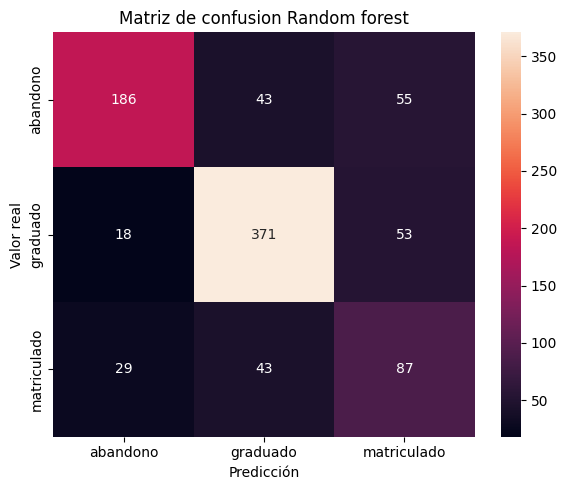

In [73]:
pipe_rf = Pipeline([('prep', preprocessor),
                    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))])

param_rf = {'clf__n_estimators': [100, 200, 300],
            'clf__max_depth': [None, 10, 20],
            'clf__min_samples_split': [2, 5],
            'clf__min_samples_leaf': [1, 2]}

rf = GridSearchCV(pipe_rf, param_grid=param_rf, cv=cv, scoring='f1_macro', n_jobs=-1)
rf.fit(X_train, y_train)

print("Mejores parámetros RF:", rf.best_params_)
print("Mejor F1-macro CV:", rf.best_score_)

# Predecimos
preds_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, preds_rf)
f1_rf = f1_score(y_test, preds_rf, average='macro')

print("Resultados en test:")
print("Accuracy: ", acc_rf)
print("F1-macro: ", f1_rf)
print(classification_report(y_test, preds_rf, target_names=le.classes_))

plot_confusion(y_test, preds_rf, le.classes_, 'Matriz de confusion Random forest')

# Guardamos resultados para la comparación final
resultados.append({'Modelo': 'Random Forest', 'Accuracy': acc_rf, 'F1_macro': f1_rf})


## Importancia de las variables (Random forest)     
Una vez entrenado el modelo de Random Forest, este permite analizar la importancia de cada variable en la predicción. Esto sirve como pista útil para ver que variables están más asociadas con la trayectoria académica de los estudiantes. Aunque, en este caso, esperamos que las variables más relevantes sean claramente las asociadas al rendimiento del primer semestre, seguidas de las notas de admisión y cualificación previa. En caso de haber mantenido las variables del segundo semestre, esas serían las más informativas sin duda.

> Además, cabe recordar que el hecho de que una variable tenga una importancia alta no significa que actuar sobre ella vaya a cambiar el resultado académico del estudiante. Lo que el modelo detecta es que esa variable está asociada con el modelo pero no que sea la causa de él.

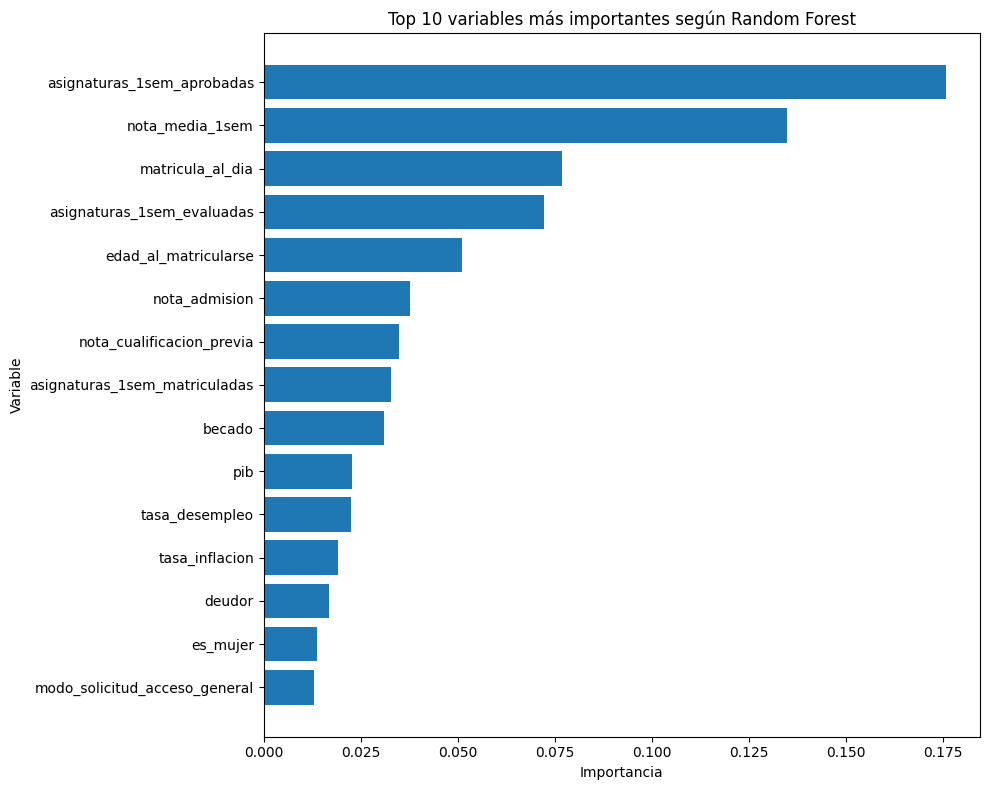

,Variable,Importancia
10,asignaturas_1sem_aprobadas,0.175670
11,nota_media_1sem,0.134651
19,matricula_al_dia,0.076949
9,asignaturas_1sem_evaluadas,0.072206
0,edad_al_matricularse,0.051029
3,nota_admision,0.037767
2,nota_cualificacion_previa,0.034839
8,asignaturas_1sem_matriculadas,0.032828
20,becado,0.030860
6,pib,0.022745


In [74]:
best_rf = rf.best_estimator_
one_hot = best_rf.named_steps['prep'].named_transformers_['cat']
feature_names = (columnas_numericas + columnas_categoricas_bin + list(one_hot.get_feature_names_out(columnas_categoricas)))

importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": best_rf.named_steps['clf'].feature_importances_}).sort_values(by="Importancia", ascending=False)

# Muestro solo con las 15 primeras
top15 = importance_df.head(15).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(top15["Variable"], top15["Importancia"])
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 10 variables más importantes según Random Forest")
plt.tight_layout()
plt.show()

display(importance_df.head(15))

# Comparación final de modelos     
Finalmente, comparamos los tres modelos usando Accuracy y F1-macro. En un problema multiclase con clases desbalanceadas, F1-macro suele ser más informativo que accuracy, ya que exige un buen rendiemiento de todas las clases por igual, pero vamos a mostrar los dos.

Aunque sabemos que Random Forest es el mejor de los tres modelos (como ya hemos visto en las matrices de confusión anteriores), podemos mostrar una comparación para verlo más claro. 

In [75]:
df_resultados = pd.DataFrame(resultados).sort_values("F1_macro", ascending=False)
df_resultados

,Modelo,Accuracy,F1_macro
2,Random Forest,0.727684,0.678808
1,Regresión Logística,0.692655,0.644916
0,KNN,0.651977,0.534684


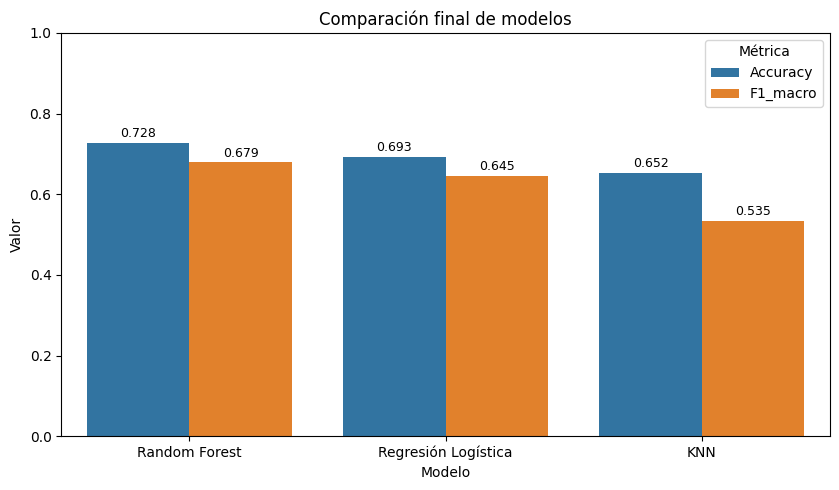

In [76]:
resultados_plot = df_resultados.melt(id_vars="Modelo",var_name="Métrica", value_name="Valor")

plt.figure(figsize=(8.5, 5))

ax = sns.barplot(data=resultados_plot,x="Modelo",y="Valor",hue="Métrica")
ax.set_title("Comparación final de modelos")
ax.set_ylim(0, 1)
ax.set_ylabel("Valor")
ax.set_xlabel("Modelo")

for cont in ax.containers:
    ax.bar_label(cont, fmt="%.3f", padding=2, fontsize=9)

plt.tight_layout()
plt.show()

## Conclusiones     
Podemos concluir que la clasificación de la trayectoria académica sí es abordable con los datos disponibles. 

Aunque los resultados obtenidos no son especialmente buenos, se podría decir que son razonables dada la predicción que queremos realizar. Es dificil saber si un estudiante va a abandonar, continuar o graduarse porque cada estudiante es muy diferente y aunque tengan el mismo perfill socioeconómico pueden tener trayectorias distintas. Además, es un resultado que depende de muchos factores que los datos no recogen, como podría ser la motivación personal, el apoyo emocional del entorno, problemas de salud o simplemente haber encontrado un trabajo a mitad de carrera y haber abandonado.

Por otra parte, Random forest es el mejor modelo (como esperabamos) y KNN el peor. La diferencia entre accuracy y F1-macro en todos los modelos indica que ninguno clasifica igual de bien las tres clases. 

También hay que tener en cuenta que excluir las variables del segundo semestre baja mucho las métricas.
